In [1]:
# These modules are required for the data reduction.
import numpy as np
from astropy import units as u
from dysh.util.files import dysh_data
from dysh.spectra.spectrum import Spectrum
from dysh.fits.gbtfitsload import GBTFITSLoad

from dysh.log import init_logging
from pathlib import Path

In [2]:
init_logging(2)

# also create a local "output" directory where temporary notebook files can be stored.
output_dir = Path.cwd() / "output"
output_dir.mkdir(exist_ok=True)

In [3]:
filename = dysh_data(test="getps")      # AGBT05B_047_01/AGBT05B_047_01.raw.acs
sdfits = GBTFITSLoad(filename)

16:07:14.306 I Resolving test=getps -> AGBT05B_047_01/AGBT05B_047_01.raw.acs/


16:07:14.426 I Index loaded from .index file (44/93 columns). Missing columns (TCAL, WCS, calibration metadata, etc.) will be automatically loaded from FITS file when first accessed.


In [4]:
sdfits.summary()

SCAN,OBJECT,VELOCITY,PROC,PROCSEQN,RESTFREQ,# IF,# POL,# INT,# FEED,AZIMUTH,ELEVATION
51,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,198.3431,18.6427
52,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,198.9306,18.7872
53,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,199.3305,18.3561
54,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,199.9157,18.4927
55,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,200.3042,18.0575
56,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,200.8906,18.1860
57,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,202.3275,17.3853
58,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,202.9192,17.4949


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


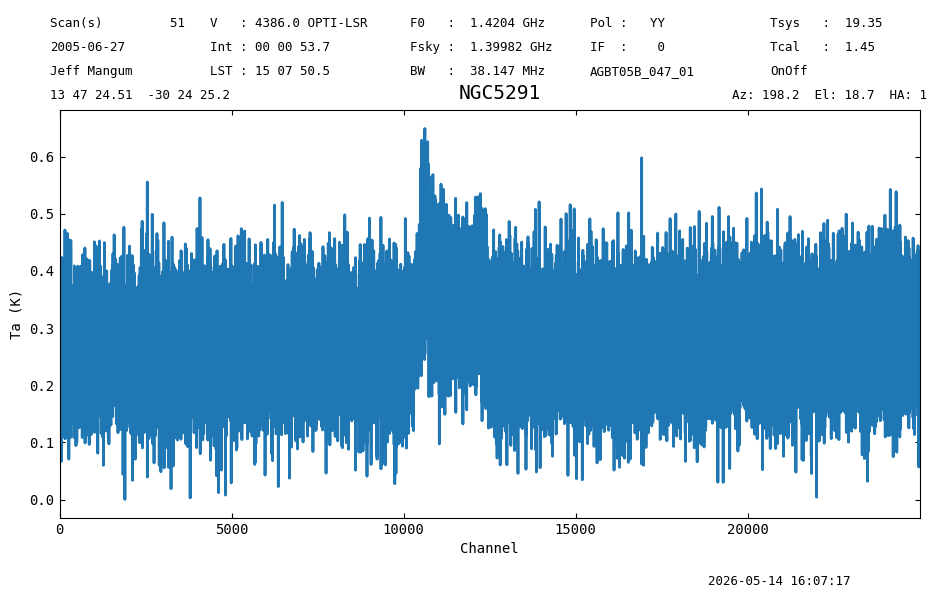

In [5]:
sp1 = sdfits.getps(scan=51, ifnum=0, plnum=0, fdnum=0).timeaverage()[5000:30000]
plot1 = sp1.plot(xaxis_unit='chan');

In [6]:
# First 10,000 channels.
sp1[:10000].stats()

{'mean': <Quantity 0.26528673 K>,
 'median': <Quantity 0.26475095 K>,
 'rms': <Quantity 0.07121472 K>,
 'min': <Quantity 0.00017927 K>,
 'max': <Quantity 0.55562309 K>,
 'npt': 10000,
 'nan': np.int64(0)}

In [7]:
# Last 10,000 channels.
sp1[-10000:].stats()

{'mean': <Quantity 0.28550266 K>,
 'median': <Quantity 0.28676712 K>,
 'rms': <Quantity 0.07194848 K>,
 'min': <Quantity 0.00420958 K>,
 'max': <Quantity 0.59789101 K>,
 'npt': 10000,
 'nan': np.int64(0)}

In [8]:
print(sp1[:10000].stats(roll=2)["rms"])
print(sp1[-10000:].stats(roll=2)["rms"])

0.07129852680478319 K


0.07117563979673235 K


In [9]:
sp1[:10000].roll(4)

[np.float64(1.0135264184344186),
 np.float64(0.998824594091855),
 np.float64(1.0009603155106295),
 np.float64(1.0088321963615878)]

In [10]:
sp1[-10000:].roll(4)

[np.float64(0.9999156099029664),
 np.float64(1.0108582257308134),
 np.float64(1.0084001989693765),
 np.float64(0.9975490048638298)]

In [11]:
sp1.radiometer()

np.float64(1.1252550964360961)

In [12]:
print(sp1[:10000].radiometer(), sp1[-10000:].radiometer())

1.0534482574016264 1.064302431580704


In [13]:
Spectrum.fake_spectrum(nchan=32768, seed=123).radiometer()

np.float64(1.000493959432403)

In [14]:
print(sp1[:10000].normalness())
print(sp1[-10000:].normalness())

0.598849482951862
0.3155802929161549


/bigdisk/src/dysh/src/dysh/spectra/spectrum.py:613: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  anderson_test = anderson(self.data)
/bigdisk/src/dysh/src/dysh/spectra/spectrum.py:613: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteC

In [15]:
print(sp1.normalness())

2.577911948763439e-09


In [16]:
sp1.baseline(degree=2, model="poly", exclude=[10000,13000], remove=True)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


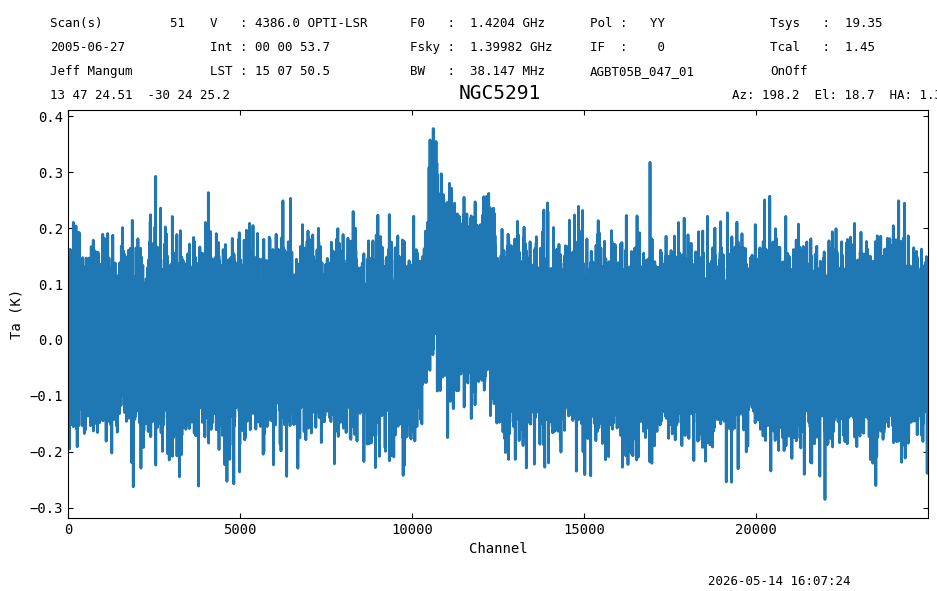

In [17]:
sp1.plot(xaxis_unit='chan');

In [18]:
sp1[:10000].stats()

{'mean': <Quantity -2.26296993e-05 K>,
 'median': <Quantity -0.00075626 K>,
 'rms': <Quantity 0.07116939 K>,
 'min': <Quantity -0.26237536 K>,
 'max': <Quantity 0.29259242 K>,
 'npt': 10000,
 'nan': np.int64(0)}

In [19]:
sp1[-10000:].stats()

{'mean': <Quantity -0.00022584 K>,
 'median': <Quantity 0.00077847 K>,
 'rms': <Quantity 0.071728 K>,
 'min': <Quantity -0.28504302 K>,
 'max': <Quantity 0.31773396 K>,
 'npt': 10000,
 'nan': np.int64(0)}

In [20]:
print(sp1[:10000].snr(), sp1[-10000:].snr())

4.164491209380743 4.418897606868031


In [21]:
print(sp1[:10000].snr(flux=True))
print(sp1[-10000:].snr(flux=True))
print(sp1[10000:13000].snr(flux=True))

-0.032206540254441474


-0.31387167706379776


47.65735422463844


In [22]:
sp1.snr()

np.float64(5.20271770740002)

In [23]:
print(sp1[:10000].sratio())

-0.000399268816406737


In [24]:
print(sp1[-10000:].sratio())

-0.003947589621889838


In [25]:
print(sp1[10000:13000].sratio())

0.7404518589686879


In [26]:
# redo the tests
print(sp1[:10000].stats())
print(sp1[:10000].stats(roll=1))
print("ROLL",sp1[:10000].roll(4))


print(sp1[-10000:].stats())
print(sp1[-10000:].stats(roll=1))
print("ROLL",sp1[-10000:].roll(4))

{'mean': <Quantity -2.26296993e-05 K>, 'median': <Quantity -0.00075626 K>, 'rms': <Quantity 0.07116939 K>, 'min': <Quantity -0.26237536 K>, 'max': <Quantity 0.29259242 K>, 'npt': 10000, 'nan': np.int64(0)}


{'mean': <Quantity -1.91970331e-06 K>, 'median': <Quantity -0.00102835 K>, 'rms': <Quantity 0.0702643 K>, 'min': <Quantity -0.37160137 K>, 'max': <Quantity 0.35925086 K>, 'npt': 9998, 'nan': np.int64(0)}


ROLL [np.float64(1.0128811836035871), np.float64(0.9981887196390057), np.float64(1.0003230829955267), np.float64(1.0081899539027515)]
{'mean': <Quantity -0.00022584 K>, 'median': <Quantity 0.00077847 K>, 'rms': <Quantity 0.071728 K>, 'min': <Quantity -0.28504302 K>, 'max': <Quantity 0.31773396 K>, 'npt': 10000, 'nan': np.int64(0)}


{'mean': <Quantity 1.49875702e-05 K>, 'median': <Quantity 7.21955806e-06 K>, 'rms': <Quantity 0.07195455 K>, 'min': <Quantity -0.36167572 K>, 'max': <Quantity 0.36903475 K>, 'npt': 9998, 'nan': np.int64(0)}


ROLL [np.float64(0.9968514885721491), np.float64(1.0077605735034652), np.float64(1.0053100804345212), np.float64(0.9944921404674939)]


In [27]:
print(sp1[:10000].radiometer(), sp1[-10000:].radiometer())

1.052777606911913 1.0610410041607696


In [28]:
for scan in [51,53,55,57]:
    sp2 = sdfits.getps(scan=scan, ifnum=0, plnum=0, fdnum=0).timeaverage()[5000:30000]
    print(scan, sp2[:10000].radiometer(), sp2[-10000:].radiometer())

51 1.0534482574016264 1.064302431580704


53 1.040350406935904 1.0625100007245583


55 1.0583714842277552 1.0546632159969935


57 1.0434732937008275 1.0579653655733117


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


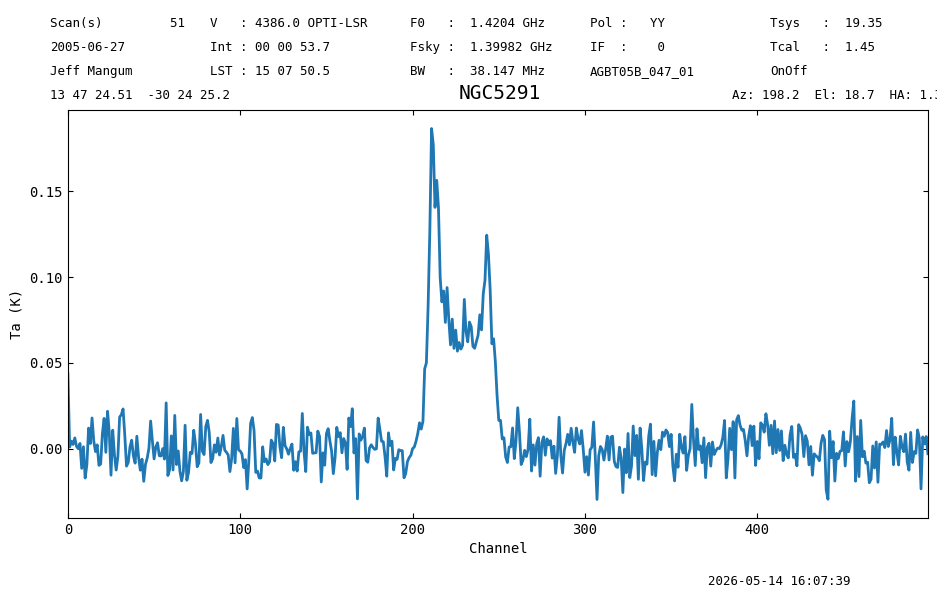

In [29]:
n = 50
method = 'hanning'
sp1s = sp1.smooth(method, n)

sp1s.plot(xaxis_unit='chan')

In [30]:
print(sp1s[:200].stats()["rms"], sp1s[-200:].stats()["rms"])

0.010752784984015664 K 0.010549863785047879 K


In [31]:
print(sp1s[:200].radiometer())
print(sp1s[-200:].radiometer())

1.1247328739459044


1.1035074757222016


In [32]:
print("Signal-to-Noise by channel")
print(sp1s[:200].snr(peak=True), sp1s[:200].snr(peak=False), 'left side')
print(sp1s[-200:].snr(peak=True), sp1s[-200:].snr(peak=False), 'right side')
print(sp1s[200:260].snr(peak=True), sp1s[200:260].snr(peak=False), 'central signal portion')

Signal-to-Noise by channel


4.484230565824742 3.0157797607093038 left side


2.641517296843382 2.798766304762895 right side


9.702435844984779 5.432313027221527 central signal portion


In [33]:
print("Signal-to-Noise by flux")
print(sp1s[:200].snr(flux=True), 'left side')
print(sp1s[-200:].snr(flux=True), 'right side')
print(sp1s[200:260].snr(flux=True), 'central signal portion')

Signal-to-Noise by flux


-0.154500225840378 left side


-0.24202494585771142 right side


37.169404072966664 central signal portion


In [34]:
print(sp1s[200:260].snr(flux=True, rms=sp1s[-200:].stats()["rms"]), 'center signal portion with given rms')

45.34448732737642 center signal portion with given rms


In [35]:
sp1s[200:260].sratio()

np.float64(0.9898058259803745)

In [36]:
%%time 
m=100                 # number of experiments
d=np.zeros(m)         # array containing the sratio values
n=32768               # largest size of spectrum

for nchan in [n, n//4, n//4//4, n//4//4//4]:
    for i in range(m):
        sp = Spectrum.fake_spectrum(nchan=nchan, seed=i, use_wcs=False)  # no WCS to save time
        sp._data = sp._data - 0.1     # current fake_spectrum has hardcoded mean 0.1 - sp.data has no setter
        d[i] = sp.sratio()
    print(d.mean(),d.std(),nchan,m)

2.5915644138168736e-05 0.007231368209840565 32768 100


0.0012918880805727934 0.014393322246256487 8192 100


0.0004981238315851011 0.029646394585039575 2048 100


0.008433098305909085 0.05710832059113764 512 100
CPU times: user 9.47 s, sys: 21 ms, total: 9.5 s
Wall time: 9.49 s


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


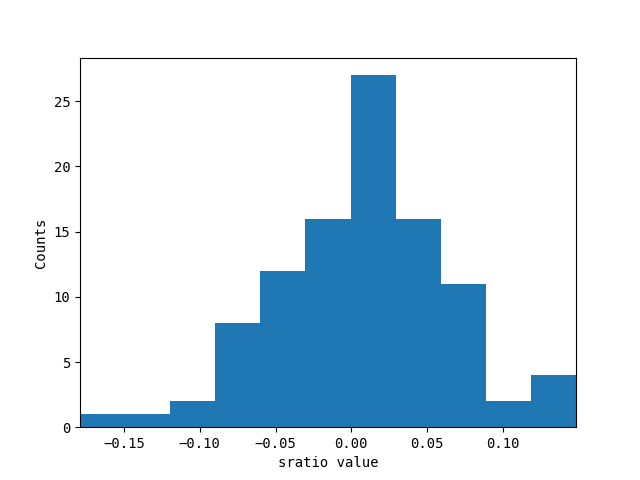

In [37]:
# plot histogram of last nchan loop with 512 channels
import matplotlib.pyplot as plt
plt.hist(d, bins="auto");
plt.xlabel("sratio value");
plt.ylabel("Counts")
plt.show()

In [38]:
sp1s.cog()

16:07:55.620 I Velocity frame: Topocentric


16:07:55.621 I Doppler convention: optical


{'flux': <Quantity 60.7548381 K km / s>,
 'flux_std': <Quantity 1.67196758 K km / s>,
 'flux_r': <Quantity 29.4009652 K km / s>,
 'flux_r_std': <Quantity 1.94644775 K km / s>,
 'flux_b': <Quantity 31.41728474 K km / s>,
 'flux_b_std': <Quantity 1.46281975 K km / s>,
 'width': {0.25: <Quantity 215.4868403 km / s>,
  0.65: <Quantity 447.54977747 km / s>,
  0.75: <Quantity 513.85353672 km / s>,
  0.85: <Quantity 580.15733259 km / s>,
  0.95: <Quantity 679.61310541 km / s>},
 'width_std': {0.25: <Quantity 33.22178748 km / s>,
  0.65: <Quantity 16.80630176 km / s>,
  0.75: <Quantity 33.54775629 km / s>,
  0.85: <Quantity 33.65571145 km / s>,
  0.95: <Quantity 33.8413805 km / s>},
 'A_F': np.float64(1.068580045741498),
 'A_C': np.float64(1.2116639031279515),
 'C_V': np.float64(2.692309803187622),
 'rms': <Quantity 0.01055038 K>,
 'bchan': np.int64(185),
 'echan': np.int64(267),
 'vel': <Quantity 4382.45068039 km / s>,
 'vel_std': <Quantity 440.84330695 km / s>,
 'vframe': 'itrs',
 'doppler_c

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


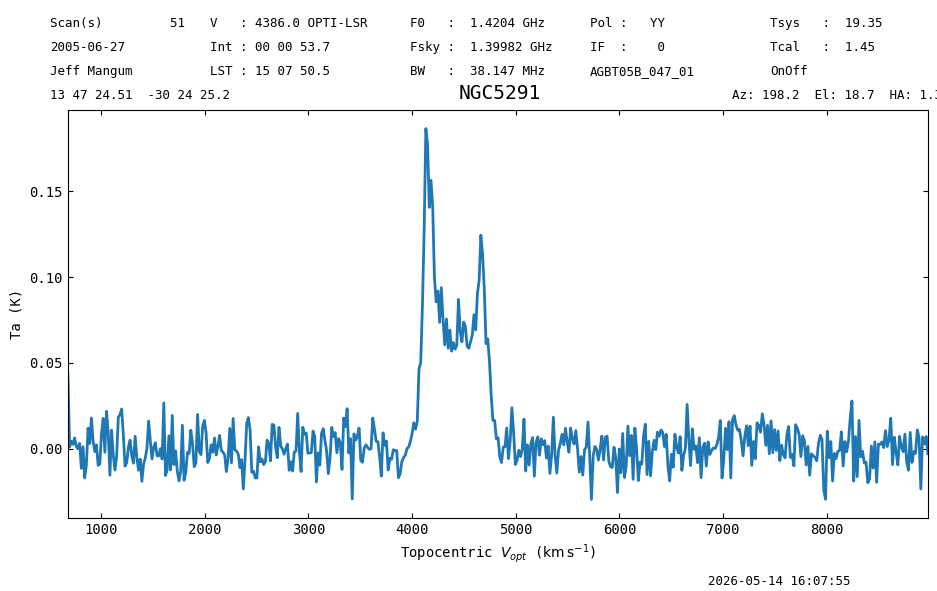

In [39]:
sp1s.plot(xaxis_unit='km/s')

In [40]:
sp1s.check_stats(0.02744442 * u.K)

16:07:56.190 I rms is OK 
